# Project 1: Dynamic Programming

### Group 1
### Osman Sultan 1006803014
### Anton Mlynczyk 1007283226
### Kevin Kim 1006820013
### Gaeun Yim 1011904824

Please read all instructions carefully before attempting each part of the problem. Each team only needs to have one submission with all the names of team-members and group number at the beginning of the jupyter notebook.

The jupyter notebook should contain your code, discussions, derivations, analysis and relevant figures. Make sure the code and plots shown in your file can be reproduce when I rerun the code in grading. Feel free to add or move Cells.

In this project, you will solve the Frozen Lake decision-making problem using dynamic programming approaches. To do this, you will first define an MDP corresponding to the Frozen Lake environment, then implement the value and policy iteration algorithms to solve the MDP you have designed. Finally, you will compare the performance of these methods with different parameters.

## 1. The Frozen Lake Environment

The Frozen Lake decision-making problem involves crossing a frozen lake from Start(S) to Goal(G) without falling
into any Holes(H) by walking over the Frozen(F) lake (Figure 1). The agent may not always move in the intended
direction due to the slippery nature of the frozen lake. The frozen lake environment is shown in Figure 1 which is
a 4x4 grid of cells. At the beginning of each episode, the agent starts at top left corner $(s_0)$ and the objective is
to reach the goal located at bottom right corner. At each cell, the agent can choose one of the left, right, up, or
down directions and moves to the corresponding adjacent cell or other adjacent cells due to the slippery nature of
the frozen lake.

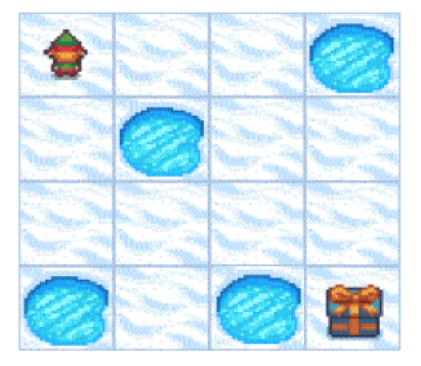

The probability of moving to the taken direction is twice of sum of all other available directions and the other
available directions are equiprobable. For example, at the top left corner, the available directions are right and
down. If the right direction is taken, the probability of transition to the right cell is 2/3 and down cell is 1/3 and
vice versa if the down direction is taken. If the agent reaches the holes (H), the mission is failed and the episode is
terminated.

### 1.1 MDP Implementation [28 Marks]

1.Model the navigation problem described above as an MDP.

(a) Define the state $(S)$ and action spaces $(A)$. [hint: The action space may not be the same for all states.]
[2 Marks]

States: $s_{ij}$, $\forall$ $i = 0, 1, 2, 3$ (row) and $\forall$ $j = 0, 1, 2, 3$ (column)

- total of 16 states
  - Initial State: $s_{00}$
  - Goal State: $s_{33}$
  - Hole States: $s_{03}$, $s_{11}$, $s_{30}$, $s_{32}$

Actions ($r$: right, $u$: up, $l$: left, $d$: down):
- $a(s_{00}) = \{r, d\}$
- $a(s_{01}) = \{r, l, d\}$
- $a(s_{02}) = \{r, l, d\}$
- $a(s_{03}) = \emptyset$
- $a(s_{10}) = \{r, u, d\}$
- $a(s_{11}) = \emptyset$
- $a(s_{12}) = \{r, l, u, d\}$
- $a(s_{13}) = \{l, u, d\}$
- $a(s_{20}) = \{r, u, d\}$
- $a(s_{21}) = \{r, l, u, d\}$
- $a(s_{22}) = \{r, l, u, d\}$
- $a(s_{23}) = \{l, u, d\}$
- $a(s_{30}) = \emptyset$
- $a(s_{31}) = \{r, l, u\}$
- $a(s_{32}) = \emptyset$
- $a(s_{33}) = \emptyset$


(b) Derive the probability transition function ($P$). [2 Marks]

$Pr(s'| a, s)$, represents the probability of transitioning from state $s$ to state $s'$ when action $a$ is taken. The probabilities are defined as follows:

Any chosen move has a probability of $\frac{2}{3}$. For all other moves, the probability is generalized as:
   $Pr(s'| a, s) = \frac{1}{3 \cdot (n-1)}$, where $n$ is the total number of possible moves from state $s$.

1. If there are 4 possible moves from state $s$:
   $Pr(s'| a, s) =
   \begin{cases}
      \frac{2}{3}, & \text{if the chosen move leads to } s', \\
      \frac{1}{9}, & \text{if any of the other moves leads to } s'.
   \end{cases}$

2. If there are 3 possible moves from state $s$:
   $Pr(s'| a, s) =
   \begin{cases}
      \frac{2}{3}, & \text{if the chosen move leads to } s', \\
      \frac{1}{6}, & \text{if any of the other moves leads to } s'.
   \end{cases}$

3. If there are 2 possible moves from state $s$:
   $Pr(s'| a, s) =
   \begin{cases}
      \frac{2}{3}, & \text{if the chosen move leads to } s', \\
      \frac{1}{3}, & \text{if the other move leads to } s'.
   \end{cases}$

4. If the state $s$ is a hole or a goal state:
   $Pr(s'| a, s) = 0$, since no moves are possible.


(c) Define one sparse and one dense reward function. Explain your answer. [hint: One example of a sparse
reward is that one only values the agent if it reaches the goal.] [2 Marks]

**Sparse reward function:**

$R(s, a) =
\begin{cases}
  1000, & \text{if } (s, a) = (s_{33}, *), \\
  0, & \text{otherwise.}
\end{cases}$

**Dense reward function:**

$R(s, a) =
\begin{cases}
  -10, & \text{if } (s, a) = (\text{hole state}, *), \\
  -\text{ManhattanDistance}(s, s_{33}) + 10, & \text{otherwise.}
\end{cases}$

2.Write down the discounted Bellman optimality equation for initial state, $V(s_0)$. Simplify your answer as much as you can. You do not need to solve it analytically. [2 Marks]

**Sparse:**
$V(s_{00}) = \max_a \Big\{ \gamma \big[\frac{2}{3} V(s_{01}) + \frac{1}{3} V(s_{10})\big], \gamma \big[\frac{2}{3} V(s_{10}) + \frac{1}{3} V(s_{01})\big] \Big\}$

**Dense:**
$V(s_{00}) = \max_a \Big\{ 5 + \gamma \big[\frac{2}{3} V(s_{01}) + \frac{1}{3} V(s_{10})\big], 5 + \gamma \big[\frac{2}{3} V(s_{10}) + \frac{1}{3} V(s_{01})\big] \Big\}$

3.Discuss how the optimal policy or policies could be, based on Figure 1. [2 Marks]

There are 3 optimal policies, each achieving the goal in 6 steps:

- $r, r, d, r, d, d$
- $r, r, d, d, r, d$
- $d, d, r, r, r, d$

**4**.Now, you are asked to implement the Frozen Lake MDP you defined above in code. Fill the missing details of $\texttt{FrozenLakeEnv}$ class in the attached Python notebook.

(a) reset() resets the environment to the initial state ($s_0$) and returns it. You must call this function at the beginning of every episode. [2 Marks]

(b) states_space() and actions_space(state) returns the state space and action space corresponding to the given state respectively. [2 Marks]

(c) pr(state, action, next_state) returns the probability of next_state given the current state and action [4 Marks]

(d) sparse_reward(state, action, next_state) and dense_reward(state, action, next_state) returns the sparse and dense reward corresponding to the given state, action and next_state. (you may not use all arguments passed to these functions). [4 Marks]

(e) step(action) performs the given action in the MDP and returns the next_state, sparse_reward, dense_reward and a boolean variable, terminated, indicates whether the episode is terminated. [6 Marks]

In [1]:
# imports
import random
from matplotlib import pyplot as plt
import seaborn as sns
import time
sns.set_style("darkgrid")

In [2]:
class FrozenLakeEnv:
    def __init__(self):

        # grid world conditions
        self.rows = 4
        self.cols = 4
        self.initial_state = (0, 0)  # start state s_00
        self.goal_state = (3, 3)  # goal state s_33
        self.hole_states = [(0, 3), (1, 1), (3, 0), (3, 2)]
        self.curr_state = self.initial_state  # current state of the agent
        self.action_map = {"r": (0, 1), "l": (0, -1), "u": (-1, 0), "d": (1, 0)}

    # Helper function 1: calculate manhattan distance between 2 states
    def manhattan_dist(self, state1, state2):
        x1, y1 = state1
        x2, y2 = state2
        return abs(x1 - x2) + abs(y1 - y2)

    # Helper function 2: return expected state after doing given action
    def expected_state_with_action(self, state, action):
        return tuple(
            map(lambda x, y: x + y, state, action)
        )  # (ex. S(0, 0) + A(0, 1) = S(0, 1))

    # Helper function 3: get all valid adjacent states
    def get_adjacent_states(self, state):
        row, col = state
        adjacent_states = []
        possible_moves = self.action_map.values()

        for move in possible_moves:
            new_row, new_col = row + move[0], col + move[1]

            if 0 <= new_row < self.rows and 0 <= new_col < self.cols:
                adjacent_states.append((new_row, new_col))

        return adjacent_states

    # return the initial state of this MDP ...
    def reset(self):
        self.curr_state = self.initial_state
        return self.curr_state

    # return a list containing all the possible states in this MDP
    def states_space(self):
        return [(i, j) for i in range(self.rows) for j in range(self.cols)]

    # return a list containing all the possible actions corresponding to the given state
    def actions_space(self, state):

        # generalization of answer in Q1.1-(a)
        if state in self.hole_states or state == self.goal_state:
            return []  # no actions available for terminal states

        x, y = state
        valid_actions = []
        if x > 0:
            valid_actions.append("u")  # up
        if x < self.rows - 1:
            valid_actions.append("d")  # down
        if y > 0:
            valid_actions.append("l")  # left
        if y < self.cols - 1:
            valid_actions.append("r")  # right

        return valid_actions

    # sparse reward function
    def sparse_reward(self, state, action, next_state):

        # return R(s, a, s’)
        return 1000 if next_state == self.goal_state else 0

    # dense reward function
    def dense_reward(self, state, action, next_state):

        # return R(s, a, s’)
        if next_state in self.hole_states:
            return -10
        return -self.manhattan_dist(next_state, self.goal_state) + 10

    # transition probability function
    def pr(self, state, action, next_state):

        # return P(s’ | s, a)
        if state in self.hole_states or state == self.goal_state:
            return 0  # no transitions for terminal states

        # Check if the next_state is within bounds
        if not (0 <= next_state[0] < self.rows and 0 <= next_state[1] < self.cols):
            return 0

        valid_actions = self.actions_space(state)
        if action not in valid_actions:  # not available action
            return 0

        ### Useful variables
        num_actions = len(
            valid_actions
        )  # number of possible actions of the input state (ex. S(0, 0) = len(['r', 'd']) = 2)
        intended_action = self.action_map[
            action
        ]  # get intended actions from dict (ex. 'r': (0, 1))
        intended_state = self.expected_state_with_action(
            state, intended_action
        )  # get expected state with given state and action (ex. S(0, 0) + A(0, 1) = S(0, 1))

        # Get probability of each case
        if next_state == intended_state:  # transition succeeds
            return 2 / 3
        elif next_state in self.get_adjacent_states(state):  # transition fails
            return 1 / (3 * (num_actions - 1))
        else:
            return 0

    def step(self, action):

        # validate the action
        valid_actions = self.actions_space(self.curr_state)
        if action not in valid_actions:
            raise ValueError("Invalid action")

        # determine the intended next state
        intended_action = self.action_map[action]
        next_state = self.expected_state_with_action(self.curr_state, intended_action)

        # Compute the rewards
        sparse_reward = self.sparse_reward(self.curr_state, action, next_state)
        dense_reward = self.dense_reward(self.curr_state, action, next_state)

        # Check termination status
        terminated = next_state in self.hole_states or next_state == self.goal_state

        # Update the current state
        self.curr_state = next_state

        # Return results
        return next_state, sparse_reward, dense_reward, terminated

In [3]:
# Testing for all methods above:
# Can be removed before submission
fl = FrozenLakeEnv()
opt_policy1 = ["r", "r", "d", "r", "d", "d"]
opt_policy2 = ["r", "r", "d", "d", "r", "d"]
opt_policy3 = ["d", "d", "r", "r", "r", "d"]

policies = [opt_policy1, opt_policy2, opt_policy3]

# reset
fl.step("r")
print(fl.curr_state)
fl.step("r")
print(fl.curr_state)
fl.reset()
print(fl.curr_state)
print("-----------------")

# states_space
states = fl.states_space()
print(f"Number of states = {len(states)}")
print(states)
print("-----------------")

# reward
for state in states:
    print(f"Sparse reward at {state} = {fl.sparse_reward(None, None, state)}")
print()
for state in states:
    print(f"Dense reward at {state} = {fl.dense_reward(None, None, state)}")
print("-----------------")

# pr
for policy in policies:
    fl.reset()
    for action in policy:
        print(f"Current state: {fl.curr_state} and intended action: {action}")
        intended_action = fl.action_map[action]
        intended_next_state = fl.expected_state_with_action(
            fl.curr_state, intended_action
        )
        all_possible_states = fl.get_adjacent_states(fl.curr_state)
        num_moves = len(all_possible_states)  # number of valid adjacent states

        # define the probability distribution
        probabilities = {}
        if num_moves > 1:  # at least 2 valid moves
            probabilities[intended_next_state] = (
                2 / 3
            )  # twice probability for the intended move
            remaining_prob = 1 / (
                3 * (num_moves - 1)
            )  # equal probability for other valid moves
            for state in all_possible_states:
                if state != intended_next_state:
                    probabilities[state] = remaining_prob
        else:  # for terminal states (goal or hole), no transitions
            probabilities[fl.curr_state] = 1

        print(probabilities)

        next_state = random.choices(
            list(probabilities.keys()), weights=list(probabilities.values()), k=1
        )[0]

        # Check termination status
        terminated = next_state in fl.hole_states or next_state == fl.goal_state

        # Update the current state
        fl.curr_state = next_state
        print(f"chosen state = {next_state}")
        print()

        if terminated:
            print("terminal")
            print("------------")
            break

# step
for policy in policies:
    fl.reset()
    path = []
    path.append(fl.curr_state)
    for action in policy:
        next, sparse, dense, term = fl.step(action)
        path.append(fl.curr_state)

    print(f"Policy: {policy}. Outcome: {path}")

(0, 1)
(0, 2)
(0, 0)
-----------------
Number of states = 16
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3)]
-----------------
Sparse reward at (0, 0) = 0
Sparse reward at (0, 1) = 0
Sparse reward at (0, 2) = 0
Sparse reward at (0, 3) = 0
Sparse reward at (1, 0) = 0
Sparse reward at (1, 1) = 0
Sparse reward at (1, 2) = 0
Sparse reward at (1, 3) = 0
Sparse reward at (2, 0) = 0
Sparse reward at (2, 1) = 0
Sparse reward at (2, 2) = 0
Sparse reward at (2, 3) = 0
Sparse reward at (3, 0) = 0
Sparse reward at (3, 1) = 0
Sparse reward at (3, 2) = 0
Sparse reward at (3, 3) = 1000

Dense reward at (0, 0) = 4
Dense reward at (0, 1) = 5
Dense reward at (0, 2) = 6
Dense reward at (0, 3) = -10
Dense reward at (1, 0) = 5
Dense reward at (1, 1) = -10
Dense reward at (1, 2) = 7
Dense reward at (1, 3) = 8
Dense reward at (2, 0) = 6
Dense reward at (2, 1) = 7
Dense reward at (2, 2) = 8
Dense reward at (2, 3) = 9
Dense reward

### 1.2 Policy Iteration Implementation [28 Marks]

In this section, you will implement the policy iteration algorithm. Then you will find the optimal greedy policy for both sparse and dense reward function using the impelemnted algorithm. Run the policies returned by the policy iteration algorithm and verify whether the agent reaches the goal. Use plots/tables to show your work for all following parts.


1.Implement the policy iteration algorithm by filling the missing functions in the $\texttt{PolicyIteration}$ class in the attached notebook. [12 Marks]

2.Run the algorithm in the $\texttt{FrozenLakeEnv}$ using both sparse_reward and dense_reward with these two discount factors $\gamma \in \{0.9, 0.99\}$. Use $\Delta=1e^{-3}$ as tolerance. [6 Marks]

3.Compare the speed of convergence for different discount factors and sparse and dense rewards. What is the best value of discount factor? Which reward function does converge faster? Why? [4 Marks]

4.Apply the greedy policy returned by the algorithm with best $\gamma$ in the Frozen Lake environment.[hint: use step(action) function you have implemented in the previous section.] [4 Marks]

5.Plot the value function of the last iteration for the different settings of discount factor and reward funtion. [hint: x-axis is a state, y-axis is the value of that state] [2 Marks]

**Question 1**

In [44]:
# Question 1
class PolicyIteration:
    def __init__(self, env, gamma, reward_type):
        # initialize the domain and discount factor
        self.env = env
        self.gamma = gamma

        self.k = 0
        self.converge = False

        self.pi = {}
        self.V = {}

        self.reward_type = reward_type


    #### need to call this to have a self.pi
    def initialize_policy(self):
        # policy iteration also requires to maintain a policy
        # initialize the policy pi_0[s] = 0 (LEFT) for all states and the value function V_0[s] = 0
        # recommend to implement the policy (self.pi) as a dictionary that maps states to actions in {LEFT, UP, RIGHT, DOWN}
        self.pi = {(i, j): 'l' for i in range(4) for j in range(4)}


    def initialize_values(self):
        # you can use the corresponding procedure you defined in ValueIteration
        self.V =  {(i, j): 0 for i in range(4) for j in range(4)}
        self.v_init = [self.V[(0,0)]]


    def compute_backup(self, state, action):
        # you can use the corresponding procedure you defined in ValueIteration
        # E{R(s, a, S’) + gamma * V_k[S’]}
        potential_states = self.env.get_adjacent_states(state)

        expectation = 0

        for next_state in potential_states:

            # use the selected reward type
            if self.reward_type == 'dense':
                reward = self.env.dense_reward(state, action, next_state)

            elif self.reward_type == 'sparse':
                reward = self.env.sparse_reward(state, action, next_state)

            else:
                raise ValueError("Invalid reward_type. Choose 'dense' or 'sparse'.")

            value = self.env.pr(state, action, next_state) * (reward + self.gamma * self.V[next_state])
            expectation += value

        return expectation


    def greedy_action(self, state):
        # use the previous function compute_backup to return the ( # deterministic) greedy action a* = pi[s] derived from V
        actions = self.env.actions_space(state)

        best_action = 'l'
        max_value = 0
        for action in actions:
            value = self.compute_backup(state, action)
            if value > max_value:
                max_value = value
                best_action = action

        return best_action


    def policy_evaluation_step(self, state): ## helper function for policy_evaluation
        # use this function to implement the policy evaluation
        # step for one iteration,
        # e.g. return the value V_{k+1}[s] = E[R(s, pi[s], S’) + gamma * V_k[S’]] # you should not modify self.V
        return self.compute_backup(state, self.pi[state])


    ## how can this ever converge?
    def policy_evaluation(self, tolerance=1e-3):
        # in policy evaluation, we solve V = P * (R + gamma * V) for a fixed policy by iterating
        # V_{k+1}[s] = E[R(s, pi[ s], S’) + gamma * V_k[S’]] for each state s until V_k converges uniformly
        # use this method to perform the necessary iterations until V_k[s] (self.V) converges to within the specified tolerance
        # this procedure should not return a value, but should modify self.V ...
        delta = 0
        states = self.env.states_space()

        while (delta < tolerance):
            delta = 0

            for state in states:
                v = self.V[state]
                self.V[state] = self.policy_evaluation_step(state)
                delta = max(delta, abs(v - self.V[state]))


    def policy_improvement(self):
        # implement the procedure here for policy improvement,
        # e.g. pi_{k+1}[s] = argmax_a E[R(s, a, S’) + gamma * V_k[S]]
        states = self.env.states_space()
        stable = True

        for state in states:
            curr_pol = self.pi[state]
            new_pol = self.greedy_action(state)
            self.pi[state] = new_pol

            if curr_pol != new_pol:
                stable = False

        return stable


    def policy_iteration(self, tolerance=1e-3):
        # implement the complete policy iteration algorithm using the procedures you defined earlier
        # your method should include initialization of the policy and value function,
        # and perform each iteration of policy iteration ,
        # which includes policy evaluation followed by improvement, until the policy no longer improves
        # you should perform monitoring and plotting the value function at the initial state,
        # store , and when converged plot , the backed -up value
        # function at the initial state of the MDP according to
        # the greedy policy derived from V_k as a function of k
        # also, print the final greedy policy in the console ...
        # k = 0

        # init
        self.initialize_policy()
        self.initialize_values()

        # monitoring
        # v_init = [self.V[(0,0)]]

        # evaluate and improve
        # converge = False

        while not self.converge:

            self.policy_evaluation(tolerance)
            stable = self.policy_improvement()

            self.k += 1
            self.v_init.append(self.V[(0,0)])

            if stable:
                self.converge = True
        
        print(f"Greedy Policy: {self.pi}")
        
        return self.V, self.pi
    
    def plot_policy_iteration(self):
        plt.plot(range(0, self.k+1), self.v_init)
        plt.xticks(range(0, self.k+1))
        plt.xlabel('iterations')
        plt.ylabel('value function')

**Question 2**

Gamma = 0.9 and Reward = dense
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
	Value Function: {(0, 0): 15.734030224999998, (0, 1): 15.378989636249996, (0, 2): 19.9092859626875, (0, 3): 0.0, (1, 0): 15.076191146249997, (1, 1): 0.0, (1, 2): 25.671508021944444, (1, 3): 25.80824263698479, (2, 0): 19.312393420187497, (2, 1): 24.680797092671526, (2, 2): 27.937191389599164, (2, 3): 28.96688456264055, (3, 0): 0.0, (3, 1): 16.14181158893625, (3, 2): 0.0, (3, 3): 0.0} 
	Optimal Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}



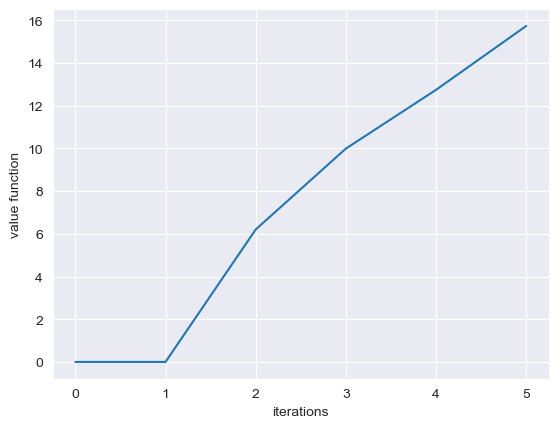

In [46]:
env = FrozenLakeEnv()

# discount factor = 0.9
gamma = 0.9

# dense with discount of 0.9
print(f"Gamma = {gamma} and Reward = dense")
policy_iter = PolicyIteration(env, gamma, 'dense')
V, policy = policy_iter.policy_iteration()
print(f"\tValue Function: {V} \n\tOptimal Policy: {policy}\n")
policy_iter.plot_policy_iteration()

Gamma = 0.9 and Reward = sparse
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
	Value Function: {(0, 0): 21.6, (0, 1): 115.54200000000002, (0, 2): 252.27645, (0, 3): 0.0, (1, 0): 99.90000000000002, (1, 1): 0.0, (1, 2): 422.36007624999996, (1, 3): 564.4667670624999, (2, 0): 226.4454, (2, 1): 385.53248999999994, (2, 2): 581.9020122499999, (2, 3): 838.6219835635416, (3, 0): 0.0, (3, 1): 231.31949399999996, (3, 2): 0.0, (3, 3): 0.0} 
	Optimal Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}



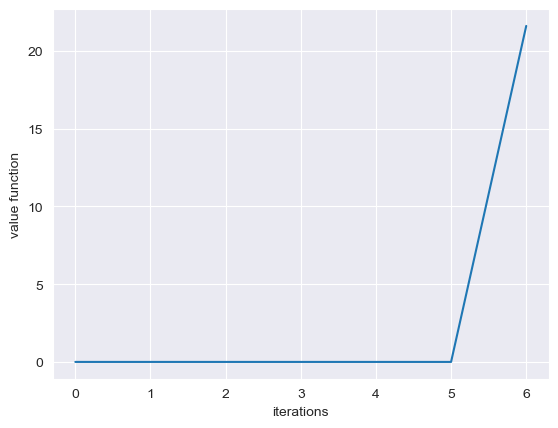

In [47]:
# sparse with discount of 0.9
print(f"Gamma = {gamma} and Reward = sparse")
policy_iter = PolicyIteration(env, gamma, 'sparse')
V, policy = policy_iter.policy_iteration()
print(f"\tValue Function: {V} \n\tOptimal Policy: {policy}\n")
policy_iter.plot_policy_iteration()

Gamma = 0.99 and Reward = dense
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
	Value Function: {(0, 0): 18.917694813737658, (0, 1): 19.378405321207754, (0, 2): 25.485511706767234, (0, 3): 0.0, (1, 0): 18.94276827398648, (1, 1): 0.0, (1, 2): 32.98836475475452, (1, 3): 33.62906464675923, (2, 0): 24.669819417248693, (2, 1): 31.72912807847626, (2, 2): 36.249353118324564, (2, 3): 37.80670205814281, (3, 0): 0.0, (3, 1): 22.274557865127665, (3, 2): 0.0, (3, 3): 0.0} 
	Optimal Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}



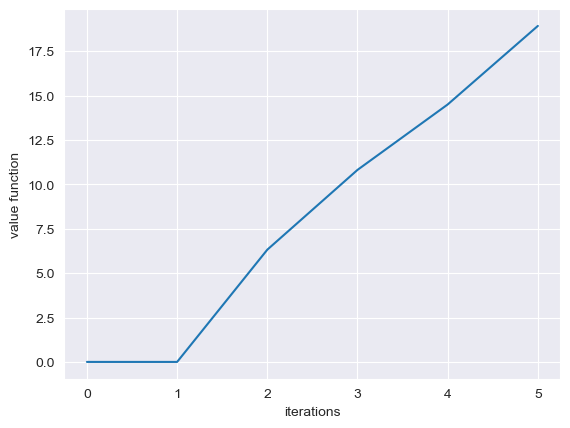

In [48]:
# discount factor = 0.99
gamma = 0.99

# dense with discount of 0.99
print(f"Gamma = {gamma} and Reward = dense")
policy_iter = PolicyIteration(env, gamma, 'dense')
V, policy = policy_iter.policy_iteration()
print(f"\tValue Function: {V} \n\tOptimal Policy: {policy}\n")
policy_iter.plot_policy_iteration()

Gamma = 0.99 and Reward = sparse
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
	Value Function: {(0, 0): 34.787015999999994, (0, 1): 173.69763226199996, (0, 2): 361.90523881429493, (0, 3): 0.0, (1, 0): 150.41431349999996, (1, 1): 0.0, (1, 2): 560.6486701065567, (1, 3): 678.0726384720739, (2, 0): 327.0018131483399, (2, 1): 517.7741306106368, (2, 2): 704.1921159833832, (2, 3): 894.7403511518171, (3, 0): 0.0, (3, 1): 341.7309262030203, (3, 2): 0.0, (3, 3): 0.0} 
	Optimal Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}



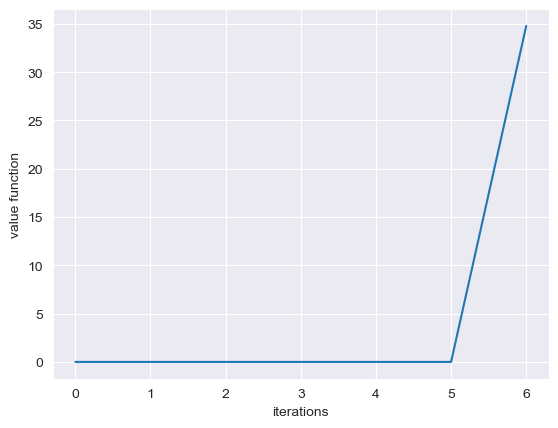

In [49]:
# sparse with discount of 0.99
print(f"Gamma = {gamma} and Reward = sparse")
policy_iter = PolicyIteration(env, gamma, 'sparse')
V, policy = policy_iter.policy_iteration()
print(f"\tValue Function: {V} \n\tOptimal Policy: {policy}\n")
policy_iter.plot_policy_iteration()


**Question 3**

In [50]:
env = FrozenLakeEnv()

gamma_best_time = float('inf')
gamma_best = 0.0
sparse_times = []
dense_times = []
gamma_times = {}
gamma = 0.1

while abs(gamma - 1.01) >= 1e-6:

    start = time.time()
    policy_iter = PolicyIteration(env, gamma, 'dense')
    _, _ = policy_iter.policy_iteration()
    end = time.time()
    dense_time = end - start
    print(f"Gamma = {gamma}, Reward = dense")
    print(f"\tConvergence Time {dense_time} seconds\n")

    start = time.time()
    policy_iter = PolicyIteration(env, gamma, 'sparse')
    _, _ = policy_iter.policy_iteration()
    end = time.time()
    sparse_time = end - start
    print(f"Gamma = {gamma}, Reward = sparse, Convergence Time {sparse_time} seconds\n")

    gamma_time = min(dense_time, sparse_time)

    if gamma_time < gamma_best_time:
        gamma_best_time = gamma_time
        gamma_best = gamma
    
    sparse_times.append(sparse_time)
    dense_times.append(dense_time)
    gamma_times[round(gamma, 2)] = [sparse_time, dense_time]

    gamma += 0.01

print("\n\n")
print(f"Best Gamma: {gamma_best} with {gamma_best_time} seconds")

avg_dense = sum(dense_times) / len(dense_times)
avg_sparse = sum(sparse_times) / len(sparse_times)
print(f"Average Dense = {avg_dense}")
print(f"Average Sparse = {avg_sparse}")

if avg_dense < avg_sparse:
    print(f"Dense function is faster on average by {avg_sparse - avg_dense}")
else:
    print(f"Sparse function is faster on average by {avg_dense - avg_sparse}")


Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Gamma = 0.1, Reward = dense
	Convergence Time 0.0015439987182617188 seconds

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Gamma = 0.1, Reward = sparse, Convergence Time 0.004305124282836914 seconds

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Gamma = 0.11, Reward = dense
	Convergence Time 0.008521080017089844 seconds

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1,

The best gamma value changes everytime the simulation of various gamma values are run. However, the best convergence time seems to be ranging +/-0.0005 seconds from 0.0035. 

Although the best gamma value changes, on average, the dense reward function dominates the sparse reward function and its convergence time is always shorter than using sparse reward.

The reason why desnse converges faster is that frequent feedback at each action helps each action become meaningful from the early stage of learning.

**Question 4**

In [51]:
env = FrozenLakeEnv()

policy_iter = PolicyIteration(env, gamma_best, 'dense')
_, policy = policy_iter.policy_iteration()
print(policy)
terminated = False
state = (0,0)

while not terminated:
    print(state)
    action = policy[state]
    state, _, _, terminated = env.step(action)

print(state)
if state == env.goal_state:
    print("Goal Reached!")
elif state in env.hole_states:
    print("Agent has fallen in the hole!")
else:
    print("Episode terminated.")
    



Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
{(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
(0, 0)
(0, 1)
(0, 2)
(1, 2)
(2, 2)
(2, 3)
(3, 3)
Goal Reached!


**Question 5**

In [52]:
env = FrozenLakeEnv()
states = [f"({i},{j})" for i in range(4) for j in range(4)]

def plot_values_policy_iter(env, gamma):
    policy_iter = PolicyIteration(env, gamma, 'dense')
    V, _ = policy_iter.policy_iteration()
    v_dense = list(V.values())

    policy_iter = PolicyIteration(env, gamma, 'sparse')
    V, _ = policy_iter.policy_iteration()
    v_sparse = list(V.values())

    plt.figure().set_figwidth(10)
    plt.plot(range(16), v_dense, label='dense')
    plt.plot(range(16), v_sparse, label='sparse')
    plt.xticks(range(16), states)
    plt.xlabel('States')
    plt.ylabel('Value Function')
    plt.legend()
    plt.title('Value Function of each state for both reward types at final iteration')

        

Gamma = 0.5

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}


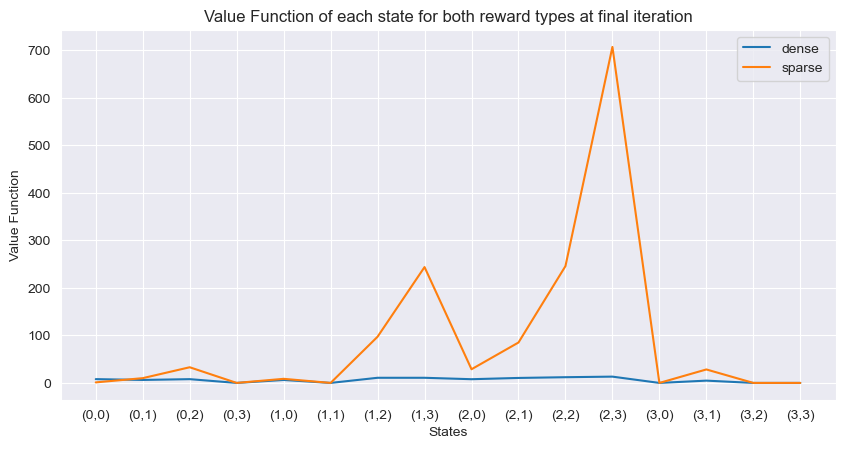

In [53]:
plot_values_policy_iter(env, 0.5)

Gamma = 0.6

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}


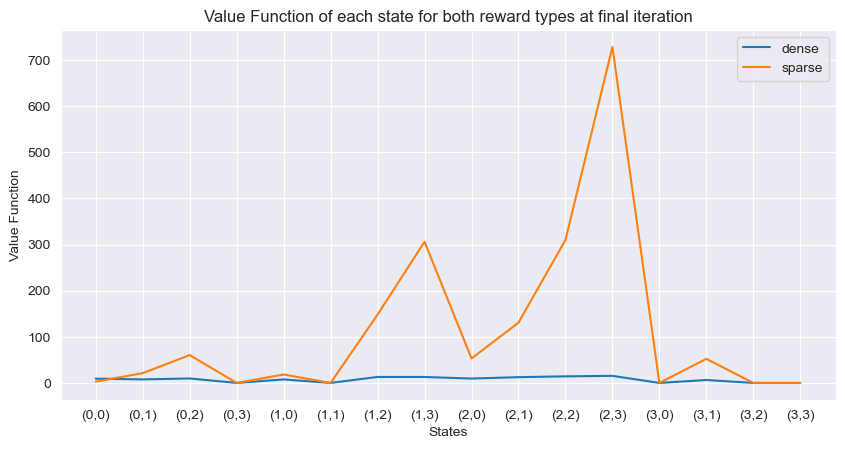

In [54]:
plot_values_policy_iter(env, 0.6)

Gamma = 0.7

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}


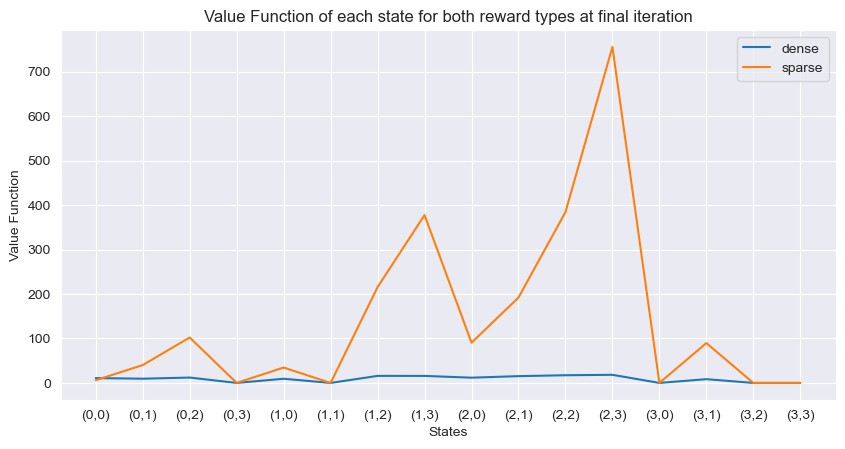

In [55]:
plot_values_policy_iter(env, 0.7)

Gamma = 0.8

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}


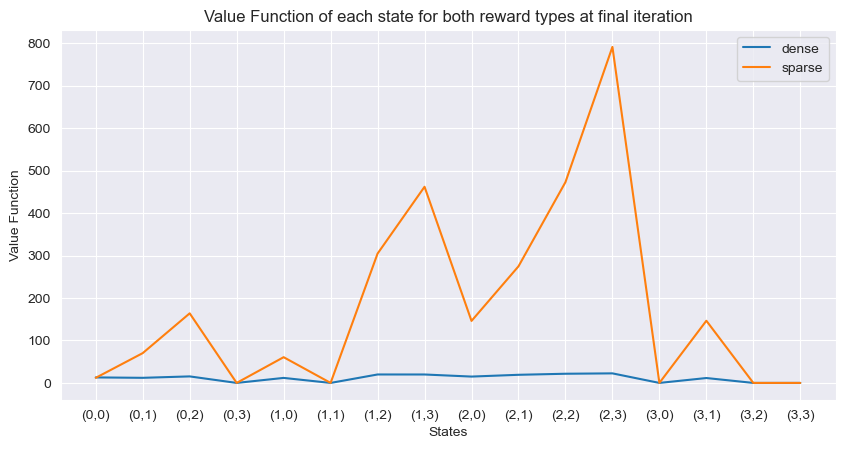

In [56]:
plot_values_policy_iter(env, 0.8)

Gamma = 0.9

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}


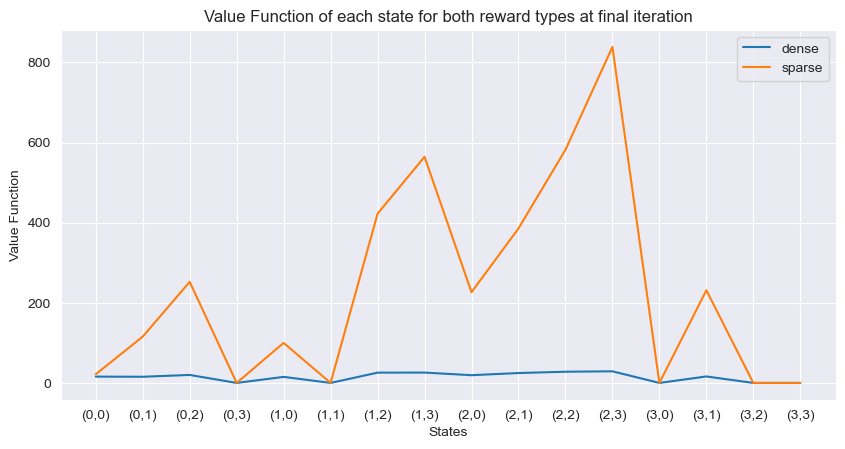

In [57]:
plot_values_policy_iter(env, 0.9)

Gamma = 0.95

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}


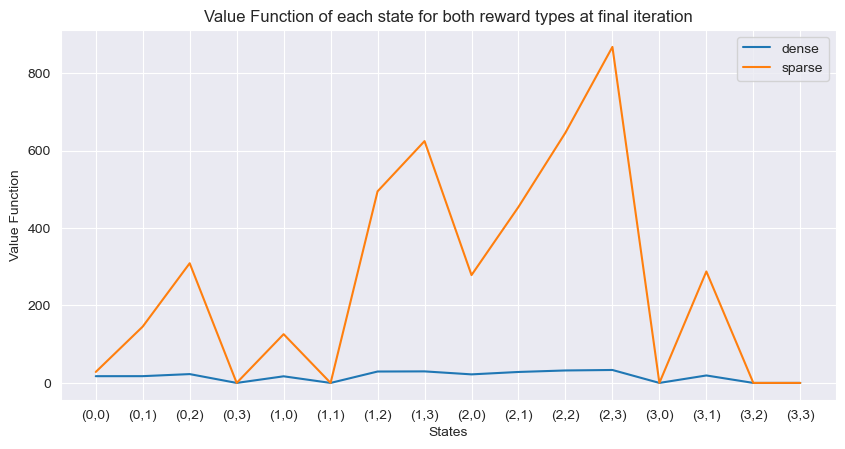

In [58]:
plot_values_policy_iter(env, 0.95)

Gamma = 0.98

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}


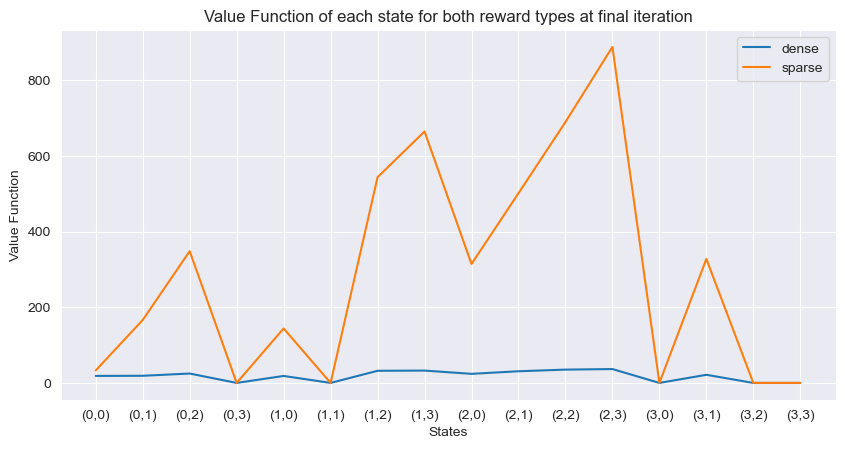

In [59]:
plot_values_policy_iter(env, 0.98)

Gamma = 0.99

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}


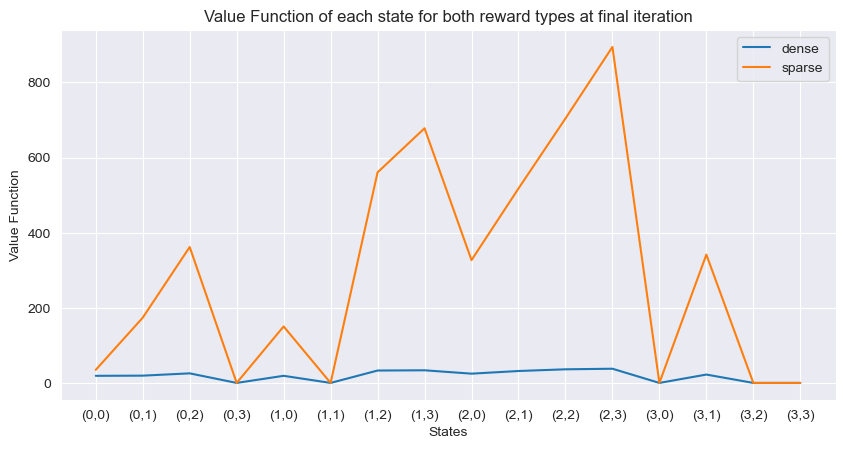

In [60]:
plot_values_policy_iter(env, 0.99)

Gamma = 1.0

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}


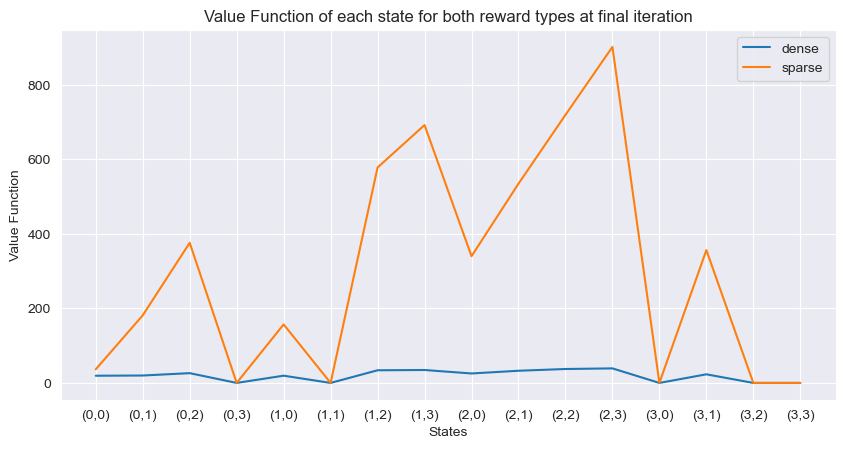

In [61]:
plot_values_policy_iter(env, 1.0)

### 1.3 Value Interation Implementation [32 Marks]

In this section, you are asked to implement the value iteration algorithm.

1.Implement the value iteration algorithm by filling the missing functions in the $\texttt{ValueIteration}$ class in the attached notebook. [16 Marks]

2.Run the algorithm in the $\texttt{FrozenLakeEnv}$ using both sparse_reward and dense_reward with these two discount factors $\gamma \in \{0.9, 0.99\}$. Use $\Delta=1e^{-6}$ as tolerance. [6 Marks]

3.Compare the speed of convergence for different discount factors and sparse and dense rewards. What is the best value of discount factor? Which reward function does converge faster? Why? [4 Marks]

4.Apply the greedy policy returned by the algorithm with best $\gamma$ in the Frozen Lake environment. [hint: use step(action) function you have implemented in the previous section.] [4 Marks]

5.Plot the value function of the last iteration for the different settings of discount factor and reward funtion. [hint: x-axis is a state, y-axis is the value of that state.] [2 Marks]

**Question 1**

In [64]:
class ValueIteration:
    def __init__(self, env, gamma, reward_type):
        # initialize the domain and discount factor
        self.env = env
        self.gamma = gamma
        self.V = {}  # value function dictionary
        self.pi = {}  # greedy policy dictionary
        self.reward_type = reward_type
        self.i = 0

    ## dictionary data form for value table recommended, but feel free to use any format for v
    def initialize_values(self):
        # you need to initialself.V = {state: 0 for state in self.env.states_space()}ize the value function V_0[s] = 0 for all states
        # implement V as a dictionary that maps states to values - this will guarantee constant-time reading and writing
        self.V = {state: 0 for state in self.env.states_space()}
        self.v_init = [self.V[(0,0)]]

    def compute_backup(self, state, action):
        # use this as a helper function to return the necessaryquantity E{R(s, a, S’) + gamma * V_k[S’]} in value iteration

        expectation = 0

        for next_state in self.env.get_adjacent_states(state):
            prob = self.env.pr(state, action, next_state)

            # use the selected reward type
            if self.reward_type == "dense":
                reward = self.env.dense_reward(state, action, next_state)
            elif self.reward_type == "sparse":
                reward = self.env.sparse_reward(state, action, next_state)
            else:
                raise ValueError("Invalid reward_type. Choose 'dense' or 'sparse'.")
            expectation += prob * (reward + self.gamma * self.V[next_state])

        return expectation

    def greedy_action(self, state):
        # use the previous function compute_backup to return the (deterministic) greedy policy pi[a | s] derived from V

        if state in self.env.hole_states or state == self.env.goal_state:
            return None  # no actions available in terminal states

        action_values = {}
        for action in self.env.actions_space(state):
            action_values[action] = self.compute_backup(state, action)

        # return the action with the maximum value
        return max(action_values, key=action_values.get)

    def update_values(self):
        # this method updates the value function for one iteration., e.g. V_{k}[s] -> V_{k+1}[s] over all s
        # it's helpful that we have V stored as one entity of value iteration object(again, just a recommendation)
        new_V = {}
        for state in self.env.states_space():
            if state in self.env.hole_states or state == self.env.goal_state:
                new_V[state] = 0  # value of terminal states is always 0
            else:
                new_V[state] = max(
                    self.compute_backup(state, action)
                    for action in self.env.actions_space(state)
                )
        self.V = new_V

    def value_iteration(self, tolerance=1e-6):
        # use this to implement the complete value iteration
        # algorithm - you should make use of the procedures initialize_values and update_values that you have written above
        # stop your iterations when the difference between V_{k+1} (self.V) and V_k (self.V_old) is less than tolerance
        # this method does not need to return anything since the
        # final V_k should be in self.V
        # store , and when converged plot , the backed -up value
        # function at the initial state of the MDP according to
        # the greedy policy derived from V_k as a function of k
        # also, print the final greedy policy in the console ...

        self.initialize_values()
        # i = 0  # iteration counter

        # monitoring
        # v_init = [self.V[(0,0)]]

        while True:
            # step 1: reset delta (max change in V(s))
            delta = 0

            # step 2: loop over all states
            for state in self.env.states_space():
                # store current value of the state
                v = self.V[state]

                # update value using bellman backup
                if state in self.env.hole_states or state == self.env.goal_state:
                    self.V[state] = v  # terminal state so just continue 
                else:
                    self.V[state] = max(
                        self.compute_backup(state, action)
                        for action in self.env.actions_space(state)
                    )

                # update delta with the maximum change in value
                delta = max(delta, abs(v - self.V[state]))

            # step 3: check convergence condition
            if delta < tolerance:
                break

            self.i += 1
            self.v_init.append(self.V[(0,0)])

        # step 4: extract greedy policy from final value function
        for state in self.env.states_space():
            self.pi[state] = self.greedy_action(state)

        print(f"Converged in {self.i} iterations.")
        print(f"Greedy Policy: {self.pi}")

    def plot_value_function(self):
        """plot the value function."""
        states = self.env.states_space()
        values = [self.V[state] for state in states]

        plt.bar(range(len(states)), values, tick_label=[f"{state}" for state in states])
        plt.xlabel("States")
        plt.ylabel("Value")
        plt.title("Value Function of the Last Iteration")

    def plot_value_iteration(self):
        plt.plot(range(0, self.i+1), self.v_init)
        plt.xticks(range(0, self.i+1))
        plt.xlabel('iterations')
        plt.ylabel('value function')

**Question 2**

Gamma = 0.9 and Reward = dense
Converged in 35 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Value Function: {(0, 0): 24.324188598868933, (0, 1): 21.615135987012966, (0, 2): 24.94417988202869, (0, 3): 0, (1, 0): 21.183691505397285, (1, 1): 0, (1, 2): 29.780960563626287, (1, 3): 28.734436037589635, (2, 0): 24.22510573731495, (2, 1): 28.69036476877774, (2, 2): 31.058868930730544, (2, 3): 31.278820097410108, (3, 0): 0, (3, 1): 18.547552194599977, (3, 2): 0, (3, 3): 0}


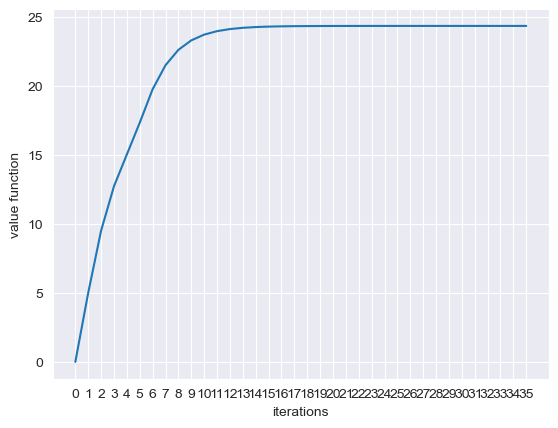

In [65]:
env = FrozenLakeEnv()

# discount factor = 0.9
gamma = 0.9

# dense with discount of 0.9
print(f"Gamma = {gamma} and Reward = dense")
value_iter = ValueIteration(env, gamma, 'dense')
value_iter.value_iteration()
print(f"Value Function: {value_iter.V}")
value_iter.plot_value_iteration()

Gamma = 0.9 and Reward = sparse
Converged in 25 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Value Function: {(0, 0): 178.94121399926243, (0, 1): 203.44678648464463, (0, 2): 294.3426740359408, (0, 3): 0, (1, 0): 189.57714085733892, (1, 1): 0, (1, 2): 439.7094267946121, (1, 3): 570.2677707322088, (2, 0): 271.2265979964067, (2, 1): 404.6500448049536, (2, 2): 588.7473038729736, (2, 3): 840.5189278574439, (3, 0): 0, (3, 1): 242.79002688297217, (3, 2): 0, (3, 3): 0}


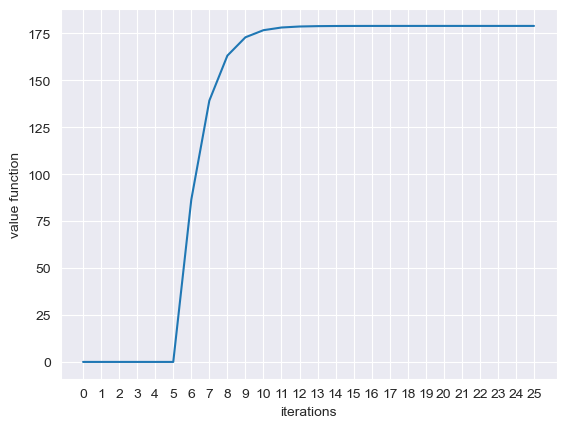

In [66]:
# sparse with discount of 0.9
print(f"Gamma = {gamma} and Reward = sparse")
value_iter = ValueIteration(env, gamma, 'sparse')
value_iter.value_iteration()
print(f"Value Function: {value_iter.V}")
value_iter.plot_value_iteration()

Gamma = 0.99 and Reward = dense
Converged in 54 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Value Function: {(0, 0): 40.83379133844194, (0, 1): 36.45370832458994, (0, 2): 40.47898961179503, (0, 3): 0, (1, 0): 35.679831891417116, (1, 1): 0, (1, 2): 46.4102950782718, (1, 3): 44.13861725174112, (2, 0): 39.30644954825737, (2, 1): 44.82718832028738, (2, 2): 47.46148618211222, (2, 3): 46.940786060064674, (3, 0): 0, (3, 1): 30.919277624723005, (3, 2): 0, (3, 3): 0}


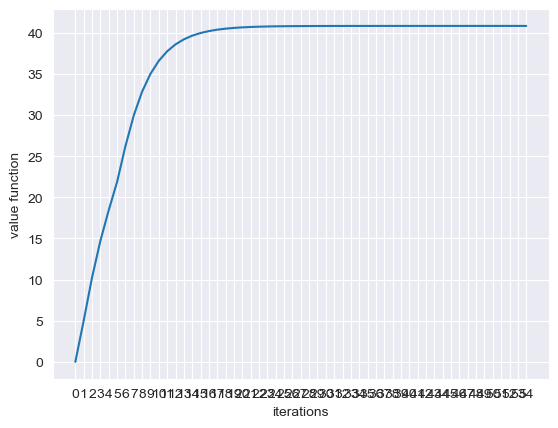

In [24]:
# discount factor = 0.99
gamma = 0.99

# dense with discount of 0.99
print(f"Gamma = {gamma} and Reward = dense")
value_iter = ValueIteration(env, gamma, 'dense')
value_iter.value_iteration()
print(f"Value Function: {value_iter.V}")

Gamma = 0.9 and Reward = sparse
Converged in 25 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Value Function: {(0, 0): 178.94121399926243, (0, 1): 203.44678648464463, (0, 2): 294.3426740359408, (0, 3): 0, (1, 0): 189.57714085733892, (1, 1): 0, (1, 2): 439.7094267946121, (1, 3): 570.2677707322088, (2, 0): 271.2265979964067, (2, 1): 404.6500448049536, (2, 2): 588.7473038729736, (2, 3): 840.5189278574439, (3, 0): 0, (3, 1): 242.79002688297217, (3, 2): 0, (3, 3): 0}


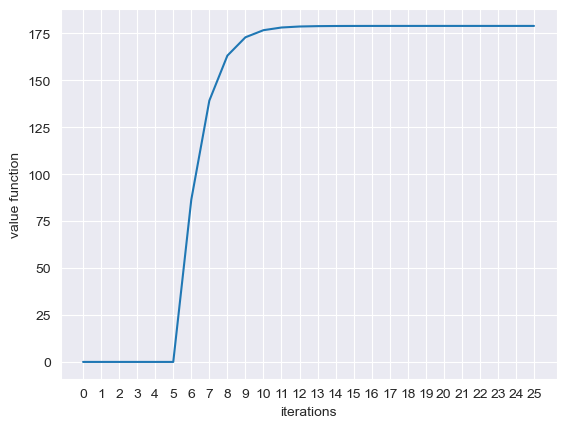

In [67]:
# sparse with discount of 0.99
print(f"Gamma = {gamma} and Reward = sparse")
value_iter = ValueIteration(env, gamma, 'sparse')
value_iter.value_iteration()
print(f"Value Function: {value_iter.V}")
value_iter.plot_value_iteration()

**Question 3**

In [68]:
env = FrozenLakeEnv()

gamma_best_time = float('inf')
gamma_best = 0.0
sparse_times = []
dense_times = []
gamma_times = {}
gamma = 0.1

while abs(gamma - 1.01) >= 1e-6:

    start = time.time()
    value_iter = ValueIteration(env, gamma, 'dense')
    value_iter.value_iteration()
    end = time.time()
    dense_time = end - start
    print(f"Gamma = {gamma}, Reward = dense")
    print(f"\tConvergence Time {dense_time} seconds\n")

    start = time.time()
    value_iter = ValueIteration(env, gamma, 'dense')
    value_iter.value_iteration()
    end = time.time()
    sparse_time = end - start
    print(f"Gamma = {gamma}, Reward = sparse, Convergence Time {sparse_time} seconds\n")

    gamma_time = min(dense_time, sparse_time)

    if gamma_time < gamma_best_time:
        gamma_best_time = gamma_time
        gamma_best = gamma
    
    sparse_times.append(sparse_time)
    dense_times.append(dense_time)
    gamma_times[round(gamma, 2)] = [sparse_time, dense_time]

    gamma += 0.01

print("\n\n")
print(f"Best Gamma: {gamma_best} with {gamma_best_time} seconds")

avg_dense = sum(dense_times) / len(dense_times)
avg_sparse = sum(sparse_times) / len(sparse_times)
print(f"Average Dense = {avg_dense}")
print(f"Average Sparse = {avg_sparse}")

if avg_dense < avg_sparse:
    print(f"Dense function is faster on average by {avg_sparse - avg_dense}")
else:
    print(f"Sparse function is faster on average by {avg_dense - avg_sparse}")


Converged in 6 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Gamma = 0.1, Reward = dense
	Convergence Time 0.034829139709472656 seconds

Converged in 6 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Gamma = 0.1, Reward = sparse, Convergence Time 0.011408090591430664 seconds

Converged in 6 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Gamma = 0.11, Reward = dense
	Convergence Time 0.0019030570983886719 seconds

C

Similar to the policy iteration analysis, the gamma value that has the shortest convergence time changes every time the code block is run since it is a difference in a few milliseconds. However, it can be seen that the shortest convergence time is achieved at around 0.01 seconds +/- 0.005.

However, it is evident that the sparse reward function leads to shorter convergence time on average.


**Question 4**

Converged in 9 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
{(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
(0, 0)
(0, 1)
(0, 2)
(1, 2)
(2, 2)
(2, 3)
(3, 3)
Goal Reached!


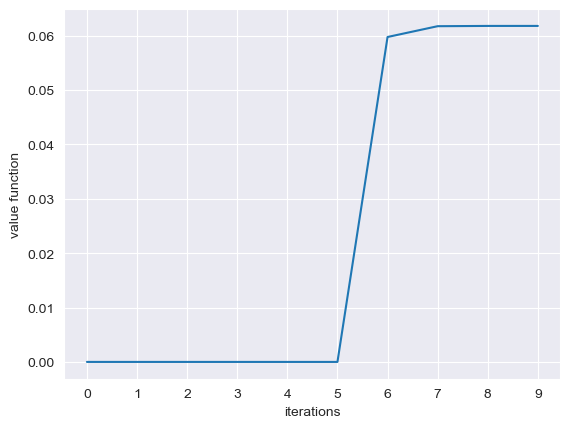

In [70]:
env = FrozenLakeEnv()

value_iter = ValueIteration(env, gamma_best, 'sparse')
value_iter.value_iteration()
value_iter.plot_value_iteration()
print(value_iter.pi)
terminated = False
state = (0,0)

while not terminated:
    print(state)
    action = policy[state]
    state, _, _, terminated = env.step(action)

print(state)
if state == env.goal_state:
    print("Goal Reached!")
elif state in env.hole_states:
    print("Agent has fallen in the hole!")
else:
    print("Episode terminated.")

**Question 5**

In [71]:
env = FrozenLakeEnv()
states = [f"({i},{j})" for i in range(4) for j in range(4)]

def plot_values_value_iter(env, gamma):
    value_iter = ValueIteration(env, gamma, 'dense')
    value_iter.value_iteration()
    v_dense = list(value_iter.V.values())

    value_iter = ValueIteration(env, gamma, 'sparse')
    value_iter.value_iteration()
    v_sparse = list(value_iter.V.values())

    plt.figure().set_figwidth(10)
    plt.plot(range(16), v_dense, label='dense')
    plt.plot(range(16), v_sparse, label='sparse')
    plt.xticks(range(16), states)
    plt.xlabel('States')
    plt.ylabel('Value Function')
    plt.legend()
    plt.title('Value Function of each state for both reward types at final iteration')

Gamma = 0.5

Converged in 13 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Converged in 13 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}


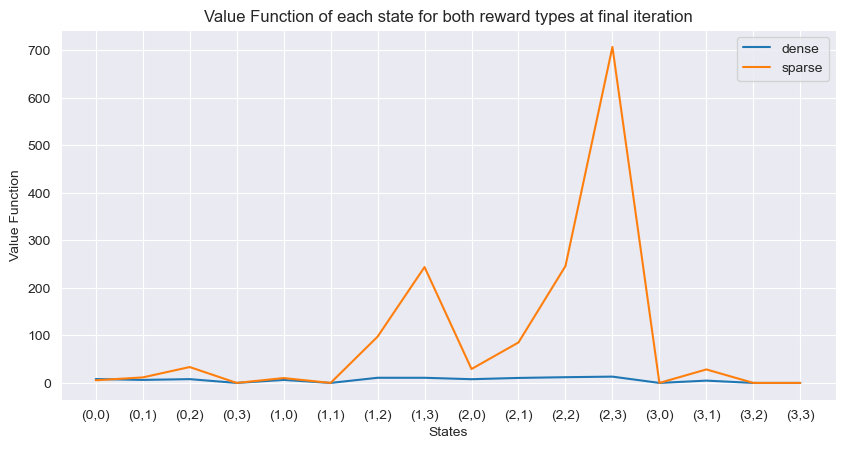

In [72]:
plot_values_value_iter(env, 0.5)

Gamma = 0.6

Converged in 15 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Converged in 15 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}


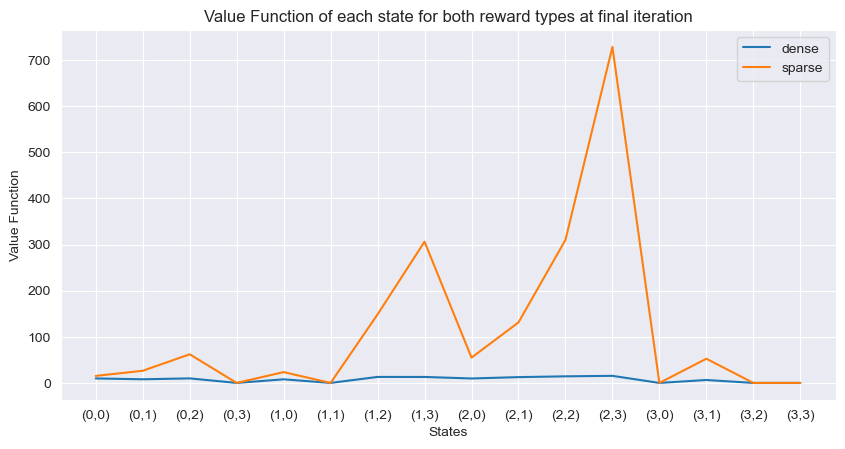

In [73]:
plot_values_value_iter(env, 0.6)

Gamma = 0.7

Converged in 19 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Converged in 17 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}


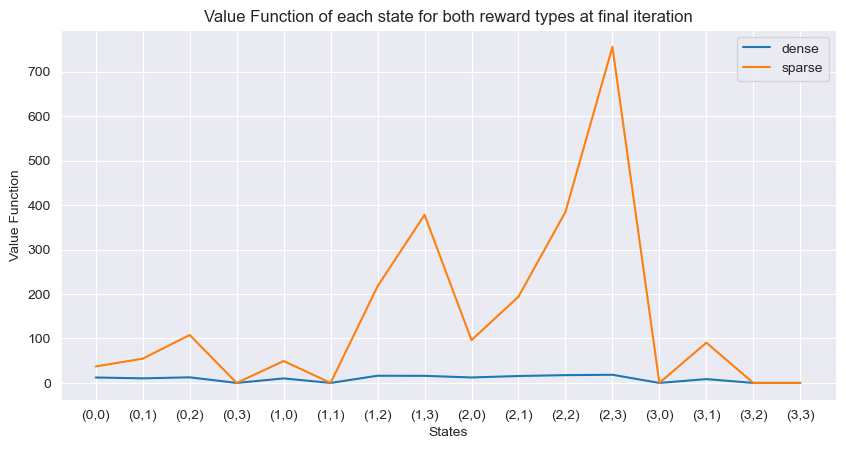

In [74]:
plot_values_value_iter(env, 0.7)

Gamma = 0.8

Converged in 25 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Converged in 21 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}


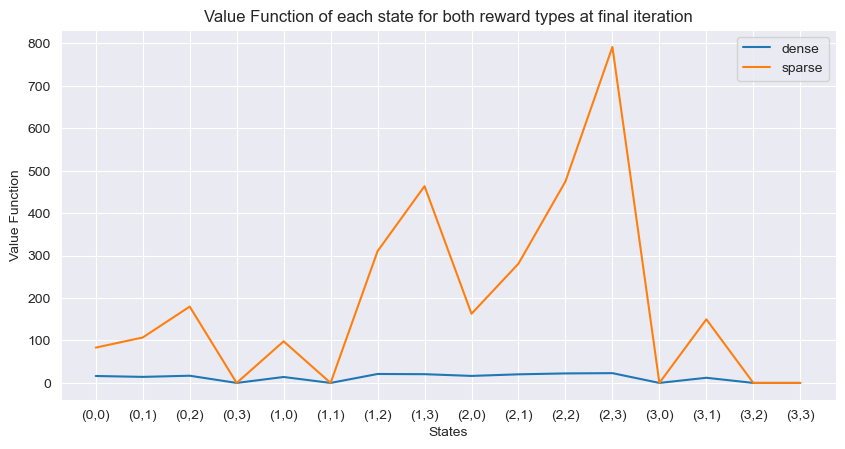

In [75]:
plot_values_value_iter(env, 0.8)

Gamma = 0.9

Converged in 35 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Converged in 25 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}


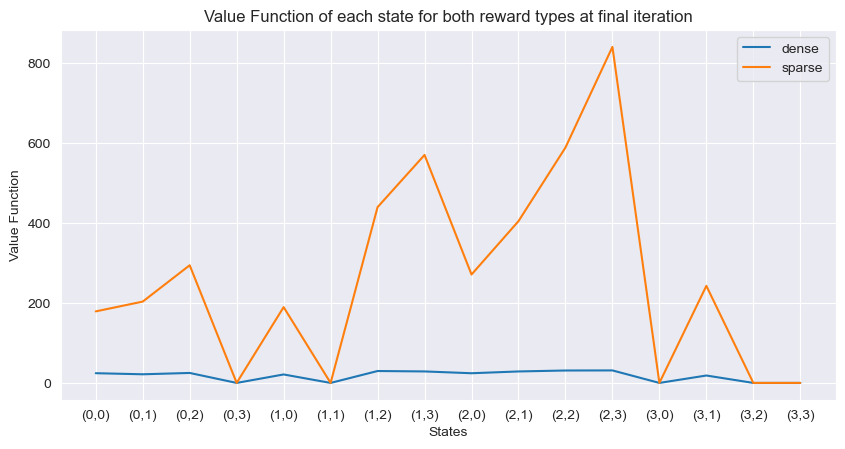

In [76]:
plot_values_value_iter(env, 0.9)

Gamma = 0.95

Converged in 44 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Converged in 27 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}


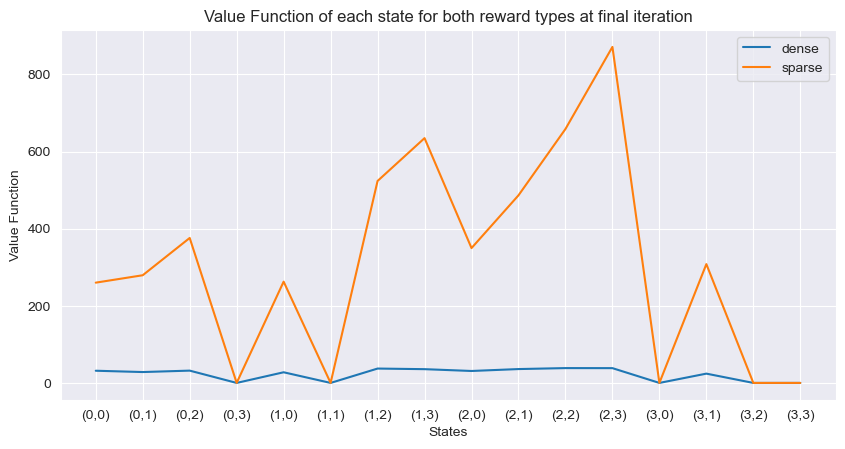

In [77]:
plot_values_value_iter(env, 0.95)

Gamma = 0.98

Converged in 51 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Converged in 29 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}


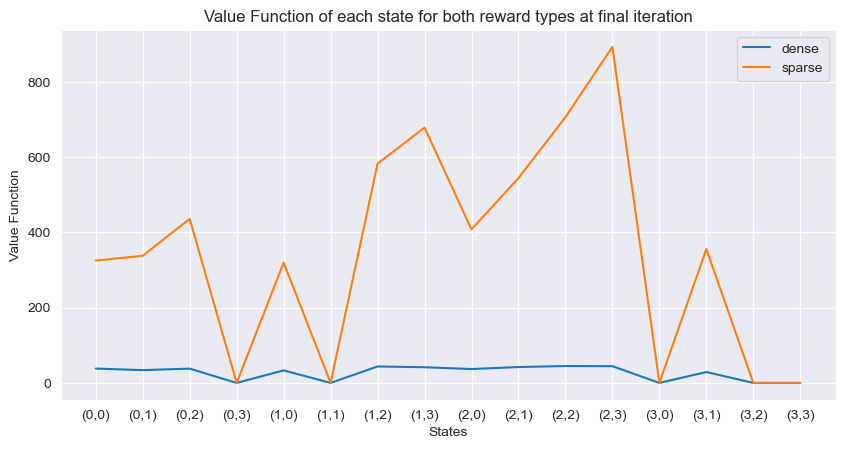

In [78]:
plot_values_value_iter(env, 0.98)

Gamma = 0.99

Converged in 54 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Converged in 30 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}


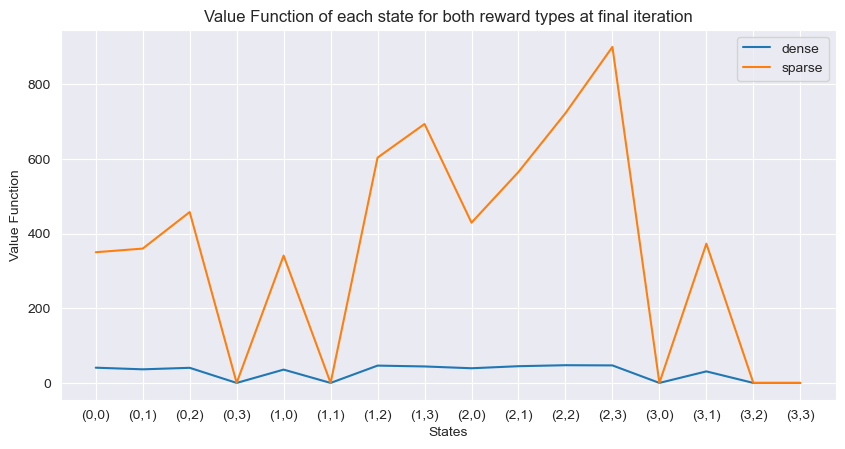

In [79]:
plot_values_value_iter(env, 0.99)

Gamma = 1.0

Converged in 58 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Converged in 30 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'd', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'd', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}


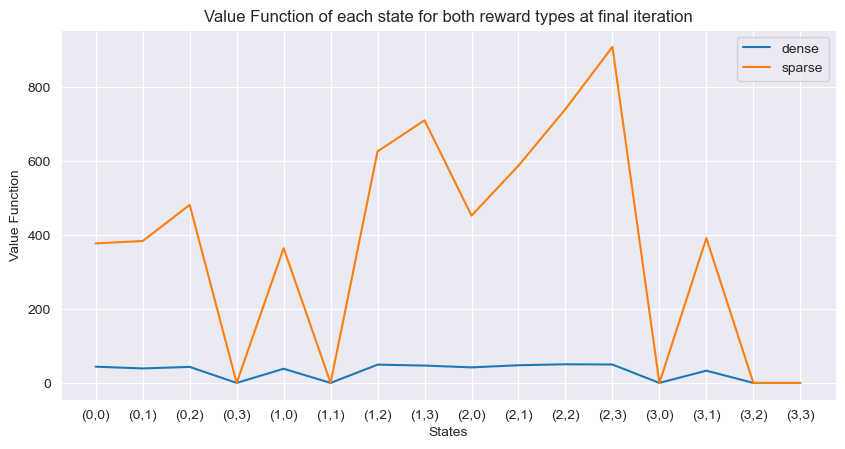

In [80]:
plot_values_value_iter(env, 1.0)

### 1.4 Comparing Algorithms [12 Marks]

Here, you are asked to compare the policy and value iteration algorithms in terms of time and memory consumption.
For assessing time consumption you can use %timeit in jupyter notebook. For assessing memory consumption,
explain the size of data structures you have used according to the state and action spaces dimension. Use plot or
table to indicate time and number of iteration of each algorithm. [12 Marks]

Part 1

Time

Record how long it takes for running policy 
Record how long it takes for running value

In [ ]:
env = FrozenLakeEnv()

start = time.time()
policy_iter = PolicyIteration(env, gamma, 'dense')
policy_iter.policy_iteration()
end = time.time()
time_policy = end - start

start = time.time()
value_iter = ValueIteration(env, gamma, 'dense')
value_iter.value_iteration()
end = time.time()
time_value = end - start

print(f"Policy iteration takes {time_policy} sec for running.")
print(f"Value iteration takes {time_value} sec for running.")

# how to remove graph?
# extracted plotting parts from policy_iteration() into plot_policy_iteration() " ditto for value 

Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): 'l', (1, 0): 'd', (1, 1): 'l', (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): 'l', (3, 1): 'u', (3, 2): 'l', (3, 3): 'l'}
Converged in 62 iterations.
Greedy Policy: {(0, 0): 'r', (0, 1): 'r', (0, 2): 'd', (0, 3): None, (1, 0): 'u', (1, 1): None, (1, 2): 'd', (1, 3): 'd', (2, 0): 'r', (2, 1): 'r', (2, 2): 'r', (2, 3): 'l', (3, 0): None, (3, 1): 'u', (3, 2): None, (3, 3): None}
Policy iteration takes 0.0067441463470458984 sec for running.
Value iteration takes 0.02574300765991211 sec for running.


Part 2

x = num_state
y = num_action

memory_consumption_policy = 2*x + y
memory_consupction_value = 3*x - y

Part 3

Time

x-axis: iteration
y-axis: time for each iteration